In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

In [13]:
df = pd.read_csv("data/DateFruit_Dataset.csv")

In [14]:
df.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


In [ ]:
df.isnull().sum()

>Null value doesn't exists in dataset

In [16]:
df.shape

(898, 35)

In [17]:
df["Class"].value_counts()

Class
DOKOL     204
SAFAVI    199
ROTANA    166
DEGLET     98
SOGAY      94
IRAQI      72
BERHI      65
Name: count, dtype: int64

> type of class: 7  => 7 output neurons

And We have to predict them.

### Data Split

In [22]:
# Data split
X = df.drop("Class", axis=1)
y = df["Class"]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Scale the data

In [23]:
# scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

### Data => tensors

In [24]:
# convert data to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
# why long: because in CrossEntropyLoss expect target(label) value as long
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

### TensorDataset & DataLoader

In [25]:
# TensorDataset
train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

### Define ANN Model 

In [26]:
# Define ANN Model for classification
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # (34 features)Input layer -> auto define by 1st hidden layer
            
            # 1st layer
            nn.Linear(X_train.shape[1], 64), # Input=34, output=64 
            nn.ReLU(),

            # 2nd layer
            nn.Linear(64, 64), # Input=64, output=64
            nn.ReLU(),

            # output layer
            # we use: Softmax AF (for: 5 classes -> 5 output neurons)
            nn.Linear(64, 7) # it give us Logits => raw scores [not probailities]
            # SoftMax by default apply by CrossEntropyLoss
        )
    
    def forward(self, x):
        return self.model(x)

#### ANN Architecture:
> 34 inpute => 64()

>Linear Combination model cannot give directly output as probailities  
it give us **Logits**  (z=wx+b)  

**Logits** : raw scores given by model (not probabilites)  
ex: 7 classes : z = [2.5, -1.5, 2.543, -1.11, .0543, 3.21, 1.223]  (random number taken)
can be any value (-ve/+ve)

### why we need logits?
Neural Network first does:
> Input -> Linear Combination -> Z(logits)

This steps:
- Combine Input
- Applies weights
- Learn patterns

But: they are not usable directly

>For convert logits -> probabilities
Apply **SoftMax AF**

When I use **CrossEntropyLoss** => so we should not apply **SoftMax**  
because in **Pytorch** CrossEntopyLoss by default apply the SoftMax

### Loss & Optimizer

In [27]:
model = ANN()

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters()) 

## Train ANN

In [28]:
train_losses = []
eval_losses = []
epochs = 100

best_eval_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # each epoch total loss

    # Iteration perform : 1 Iteration => 1 batch complete
    for xb, yb in train_loader:
        # prevents to accumulateed previous gredient
        optimizer.zero_grad() # compute new/refresh gradiend every time
        
        output = model(xb) # logits
        loss = criterion(output, yb)
        loss.backward() # gredients compute
        optimizer.step() # update parameters

        running_loss += loss.item() # tensor -> python float

    # average loss of one epoch
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    print(f"epoch {epoch+1}/{epochs} => train loss: {epoch_train_loss}")

epoch 1/100 => train loss: 1.7984537352686343
epoch 2/100 => train loss: 1.1892332227333733
epoch 3/100 => train loss: 0.7494181187256522
epoch 4/100 => train loss: 0.5623667693656423
epoch 5/100 => train loss: 0.46707082636978314
epoch 6/100 => train loss: 0.4092458292194035
epoch 7/100 => train loss: 0.36076034216777136
epoch 8/100 => train loss: 0.3234569326691005
epoch 9/100 => train loss: 0.2950663326875023
epoch 10/100 => train loss: 0.2716727146635885
epoch 11/100 => train loss: 0.25600618447946466
epoch 12/100 => train loss: 0.23510950803756714
epoch 13/100 => train loss: 0.22889167361933252
epoch 14/100 => train loss: 0.21325925413681113
epoch 15/100 => train loss: 0.20441490832878195
epoch 16/100 => train loss: 0.19691404246765634
epoch 17/100 => train loss: 0.1938398218025332
epoch 18/100 => train loss: 0.17791644451410873
epoch 19/100 => train loss: 0.16787922349960907
epoch 20/100 => train loss: 0.1591126325175814
epoch 21/100 => train loss: 0.15780641932202422
epoch 22/10

## Validation

In [30]:
model.eval()

total = 0
correct = 0
all_preds = []
all_labels = []

with torch.no_grad(): # no gradient compute
    for xb, yb in test_loader:
        output = model(xb) # 7 value
        # index is represent the class labels
        _, predicted = torch.max(output, 1) # max() => max_val , index

        all_preds.extend(predicted.tolist())
        all_labels.extend(yb.tolist())
        
        correct += (predicted == yb).sum().item()
        total += yb.size(0) # actutal sample in each batch

print("Total Prediction: ", total)
print("Correct Prediction: ", correct)
print("Acccuracy: ", correct/total * 100, "%")

Total Prediction:  180
Correct Prediction:  169
Acccuracy:  93.88888888888889 %


In [31]:
from sklearn.metrics import accuracy_score, classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       0.89      0.85      0.87        20
           2       1.00      0.96      0.98        50
           3       0.73      0.80      0.76        10
           4       1.00      0.91      0.96        35
           5       1.00      1.00      1.00        33
           6       0.80      1.00      0.89        20

    accuracy                           0.94       180
   macro avg       0.91      0.92      0.91       180
weighted avg       0.95      0.94      0.94       180



Text(70.72222222222221, 0.5, 'True label')

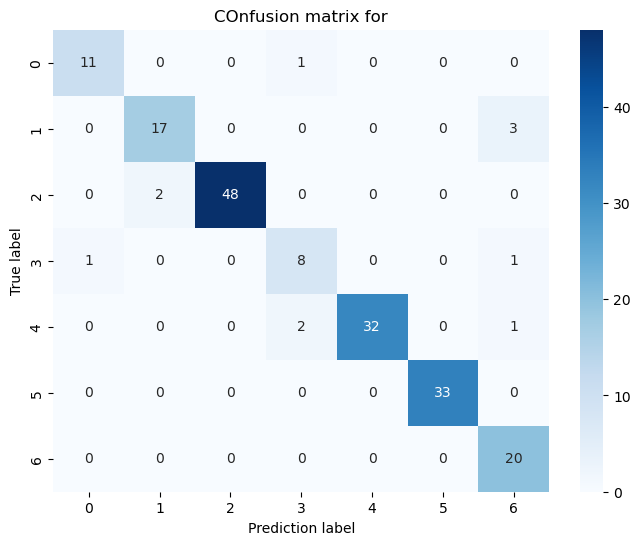

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("COnfusion matrix for")

plt.xlabel("Prediction label")
plt.ylabel("True label")